<a href="https://colab.research.google.com/github/ashioyajotham/ai_research/blob/main/Snake_game_PPO_JAX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall -y jax jaxlib
# optional: check for leftover pjrt/plugin packages and uninstall if present (example names may vary)
!pip list | grep -i pjrt || true
# if you see a pjrt plugin package: pip uninstall -y <that-package>

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
jax-cuda12-pjrt                          0.7.2


In [2]:
!pip install --upgrade "jax[cuda]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.5/150.5 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 56.3 MB/s eta 0:00:00
  Attempting uninstall: jax-cuda12-pjrt
    Found existing installation: jax-cuda12-pjrt 0.7.2
    Uninstalling jax-cuda12-pjrt-0.7.2:
      Successfully uninstalled jax-cuda12-pjrt-0.7.2
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82
  Attempting uninstall: jax-cuda12-plugin
    Found existing installation: jax-cuda12-plugin 0.7.2
    Uninstalling

In [3]:
!python - <<'PY'
import jax, sys
print("jax", jax.__version__)
print("devices:", jax.devices())
!PY

/bin/bash: line 1: warning: here-document at line 1 delimited by end-of-file (wanted `PY')
jax 0.8.1
devices: [CudaDevice(id=0)]
/bin/bash: line 1: PY: command not found


In [4]:
{
  "cell_type": "code",
  "metadata": {
    "language": "python"
  },
  "source": [
    "import os, subprocess, traceback\n",
    "print('=== System GPU info (nvidia-smi) ===')\n",
    "try:\n",
    "    out = subprocess.check_output(['nvidia-smi'], stderr=subprocess.STDOUT).decode('utf-8')\n",
    "    print(out)\n",
    "except Exception as e:\n",
    "    print('nvidia-smi not available or failed:', e)\n",
    "\n",
    "print('\\n=== JAX platform env var ===')\n",
    "print('JAX_PLATFORMS=', os.environ.get('JAX_PLATFORMS'))\n",
    "\n",
    "print('\\n=== Try import jax/jaxlib ===')\n",
    "try:\n",
    "    import jax, jaxlib\n",
    "    print('jax version:', jax.__version__)\n",
    "    try:\n",
    "        print('jaxlib version:', jaxlib.__version__)\n",
    "    except Exception:\n",
    "        print('jaxlib version: unknown')\n",
    "    try:\n",
    "        print('jax.devices():', jax.devices())\n",
    "    except Exception as e:\n",
    "        print('jax.devices() raised:', e)\n",
    "except Exception as ex:\n",
    "    print('Importing jax failed with exception:')\n",
    "    traceback.print_exc()\n",
    "    print('\\nIf you see a PJRT / plugin error mentioning \"use_tfrt_gpu_client\", follow these steps:')\n",
    "    print('  1) pip uninstall -y jax jaxlib')\n",
    "    print('  2) pip install --upgrade \"jax[cuda]\" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html')\n",
    "    print('  3) restart your kernel and re-run this cell')\n"
  ]
}

{'cell_type': 'code',
 'metadata': {'language': 'python'},
 'source': ['import os, subprocess, traceback\n',
  "print('=== System GPU info (nvidia-smi) ===')\n",
  'try:\n',
  "    out = subprocess.check_output(['nvidia-smi'], stderr=subprocess.STDOUT).decode('utf-8')\n",
  '    print(out)\n',
  'except Exception as e:\n',
  "    print('nvidia-smi not available or failed:', e)\n",
  '\n',
  "print('\\n=== JAX platform env var ===')\n",
  "print('JAX_PLATFORMS=', os.environ.get('JAX_PLATFORMS'))\n",
  '\n',
  "print('\\n=== Try import jax/jaxlib ===')\n",
  'try:\n',
  '    import jax, jaxlib\n',
  "    print('jax version:', jax.__version__)\n",
  '    try:\n',
  "        print('jaxlib version:', jaxlib.__version__)\n",
  '    except Exception:\n',
  "        print('jaxlib version: unknown')\n",
  '    try:\n',
  "        print('jax.devices():', jax.devices())\n",
  '    except Exception as e:\n',
  "        print('jax.devices() raised:', e)\n",
  'except Exception as ex:\n',
  "    pri

In [1]:
import jax
import jax.numpy as jnp
import flax.linen as nn
#!pip install distrax
import distrax
import optax
from typing import Sequence, NamedTuple
from flax.linen.initializers import constant, orthogonal
from flax.training.train_state import TrainState
import numpy as np
import gymnasium as gym
from functools import partial

In [2]:
# Configuration
config = {
    # Environment
    "ENV_NAME": "CartPole-v1",
    "NUM_ENVS": 4,

    # Training
    "TOTAL_TIMESTAMPS": 1e6,
    "NUM_STEPS": 128,
    "NUM_MINIBATCHES": 4,
    "LEARNING_RATE": 2.5e-4,

    # PPO Parameters
    "GAMMA": 0.99,
    "GAE_LAMBDA": 0.95,
    "CLIP_EPS": 0.2,
    "ENT_COEF": 0.01,
    "VF_COEF": 0.5,

    # Network
    "ACTIVATION": "tanh",
    "SEED": 42,
}

# Derived Configuration
config["NUM_UPDATES"] = int(config["TOTAL_TIMESTAMPS"] // (config["NUM_STEPS"] * config["NUM_ENVS"]))
config["MINIBATCH"] = int((config["NUM_STEPS"] * config["NUM_ENVS"]) // config["NUM_MINIBATCHES"])

In [3]:
class Transition(NamedTuple):
  """Data structure to store environment transitions"""
  done: jnp.ndarray
  action: jnp.ndarray
  value: jnp.ndarray
  reward: jnp.ndarray
  log_prob: jnp.ndarray
  obs: jnp.ndarray
  info: dict

class ActorCritic(nn.Module):
  """Actor Critic Network"""
  action_dim: int
  activation: str = "tanh"

  @nn.compact
  def __call__(self, x):
    """Defines the forward pass of the Actor Critic Network"""
    if self.activation == "relu":
      activation = nn.relu
    else:
      activation = nn.tanh

    # Shared layers
    shared = nn.Dense(64, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(x)
    shared = activation(shared)
    shared = nn.Dense(64, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(shared)
    shared = activation(shared)

    # Actor head - decides what action to take (outputs a distribution probability)
    actor_mean = nn.Dense(self.action_dim, kernel_init=orthogonal(0.01))(shared)
    pi = distrax.Categorical(logits=actor_mean)

    # Critic head - estimates how good the current state is (outputs a value score)
    value = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0))(shared)
    return pi, jnp.squeeze(value, axis=-1)

In [4]:
def make_train(config):
  """Unsure the training function with the given configuration"""

  # Initialize environment
  def make_env():
    env = gym.make(config["ENV_NAME"])
    return env

  # For now let us create a simple vectorized environment wrapper
  class SimpleVecEnv:
    def __init__(self, env_fns):
      self.envs = [env_fn() for env_fn in env_fns]
      self.num_envs = len(env_fns)
      self.observation_space = self.envs[0].observation_space
      self.action_space = self.envs[0].action_space

    def reset(self, seed=None):
      obs = []
      infos = []
      if seed is None:
          seed_list = [None] * self.num_envs
      else:
          # Assuming seed is a JAX random key array from jax.random.split
          # Convert JAX array keys to integers for gym.Env reset
          seed_list = [int(k[0]) for k in jax.random.split(seed, self.num_envs)]

      for i, env in enumerate(self.envs):
        if seed_list[i] is not None:
          o, info = env.reset(seed=seed_list[i])
        else:
          o, info = env.reset()
        obs.append(o)
        infos.append(info)
      return np.array(obs), infos

    def step(self, actions):
      obs, rewards, dones, truncated, infos = [], [], [], [], []
      # Ensure actions is an iterable of scalars (one per env)
      actions = np.asarray(actions)
      for env, action in zip(self.envs, actions):
        # action may be a 0-d array, a numpy scalar, or a JAX array; coerce to Python int
        a = int(np.array(action).item())
        o, r, d, t, info = env.step(a)
        if d or t:
          # reset the env immediately and use the new observation
          o, _ = env.reset()
        obs.append(o)
        rewards.append(r)
        dones.append(d or t)
        truncated.append(t)
        infos.append(info)

      return np.array(obs), np.array(rewards), np.array(dones), np.array(truncated), infos


  # Create vectorized environment
  env = SimpleVecEnv([make_env for _ in range(config["NUM_ENVS"])])

  # Get environment specs
  obs_shape = env.observation_space.shape
  action_dim = env.action_space.n

  def linear_schedule(count):
    """Linear learning rate schedule"""
    frac = 1.0 - (count / config["TOTAL_TIMESTAMPS"])
    return config["LEARNING_RATE"] * frac


  def train(rng):
    """Main training function"""
    print("Starting training inside train function...")

    # Initialize network
    network = ActorCritic(action_dim, config["ACTIVATION"])

    rng, _rng = jax.random.split(rng)
    init_x = jnp.zeros(obs_shape)
    network_params = network.init(_rng, init_x)

    # Initialize optimizer
    tx = optax.chain(
        optax.clip_by_global_norm(0.5),
        optax.adam(learning_rate=linear_schedule, eps=1e-5),
    )
    train_state = TrainState.create(
        apply_fn=network.apply,
        params=network_params,
        tx=tx,
    )

    # Environment step function - This will be jitted
    @jax.jit
    def env_step_fn(train_state, last_obs, rng):
      pi, value = network.apply(train_state.params, last_obs)
      rng, _rng = jax.random.split(rng)
      action = pi.sample(seed=_rng)
      log_prob = pi.log_prob(action)
      return action, value, log_prob, rng


    def calculate_gae(traj_batch, last_val):
      """Calculate Generalized Advantage Estimation"""
      def get_advantages(gae_and_next_value, transition):
        gae, next_value = gae_and_next_value
        done, value, reward = transition.done, transition.value, transition.reward

        delta = reward + config["GAMMA"] * next_value * (1 - done) - value
        gae = delta + config["GAMMA"] * config["GAE_LAMBDA"] * (1-done) * gae

        return(gae, value), gae

      _, advantages = jax.lax.scan(
          get_advantages,
          (jnp.zeros_like(last_val), last_val),
          traj_batch,
          reverse=True
      )
      return advantages, advantages + traj_batch.value

    def update_echo(update_state, unused):
      """Update function for one epoch"""
      def update_minibatch(train_state, batch_info):
        """Update function for one minibatch"""
        traj_batch, advantages, targets = batch_info

        def loss_fn(params):
          # Forward pass
          pi, value = network.apply(params, traj_batch.obs)
          log_prob = pi.log_prob(traj_batch.action)

          # Calculate policy loss
          ratio = jnp.exp(log_prob - traj_batch.log_prob)
          gae = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

          loss_actor1 = ratio * gae
          loss_actor2 = jnp.clip(ratio, 1 - config["CLIP_EPS"], 1 + config["CLIP_EPS"]) * gae
          loss_actor = -jnp.minimum(loss_actor1, loss_actor2).mean()

          # Value loss
          value_pred_clipped = traj_batch.value + (value - traj_batch.value).clip(-config["CLIP_EPS"], config["CLIP_EPS"])
          value_losses = jnp.square(value - targets)
          value_losses_clipped = jnp.square(value_pred_clipped - targets)
          value_loss = 0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()

          # Entropy loss
          entropy = pi.entropy().mean()
          total_loss = (
              loss_actor +
              config["VF_COEF"] * value_loss -
              config["ENT_COEF"] * entropy
          )
          return total_loss, (loss_actor, value_loss, entropy)

        grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
        (total_loss, loss_info), grads = grad_fn(train_state.params)
        train_state = train_state.apply_gradients(grads=grads)
        return train_state, (total_loss, loss_info)

      train_state, traj_batch, advantages, targets, rng = update_state

      rng, _rng = jax.random.split(rng)
      batch_size = config["MINIBATCH"] * config["NUM_MINIBATCHES"]
      assert batch_size == config["NUM_STEPS"] * config["NUM_ENVS"], f"batch_size {batch_size}" != "{config['NUM_STEPS'] * config['NUM_ENVS']}"

      permutation = jax.random.permutation(_rng, batch_size)
      batch = (traj_batch, advantages, targets)
      batch = jax.tree_util.tree_map(lambda x: jnp.reshape(x, (batch_size, ) + x.shape[2:]), batch)

      shuffled_batch = jax.tree_util.tree_map(lambda x: jnp.take(x, permutation, axis=0), batch,
      )
      minibatches = jax.tree_util.tree_map(lambda x: jnp.reshape(x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])), shuffled_batch,
      )

      train_state, loss_info = jax.lax.scan(update_minibatch, train_state, minibatches)
      update_state = (train_state, traj_batch, advantages, targets, rng)
      return update_state, loss_info

    # Initialize environment
    rng, _rng = jax.random.split(rng)
    reset_rng = _rng # Use the split key directly for the SimpleVecEnv reset
    obsv, infos = env.reset(reset_rng)
    obsv = jnp.array(obsv)
    env_state = obsv # Assuming env_state is the observation

    # Training loop
    runner_state = (train_state, env_state, obsv, rng)
    print(f"Starting training loop for {config['NUM_UPDATES']} updates...")

    # Collect loss history for plotting
    loss_history = []


    # Log progress - This part needs to be inside a loop over updates
    # The previous code had an outer loop for updates, which was removed
    # Re-introduce the outer loop for updates
    @jax.jit
    def train_step_fn(runner_state, update_count):
        train_state, env_state, last_obs, rng = runner_state

        # Collect rollout data in a Python loop - This cannot be inside JAX jit/scan
        # Moving environment interaction outside of train_step_fn

        # Calculate advantages
        _, last_val = network.apply(train_state.params, last_obs)
        advantages, targets = calculate_gae(traj_batch, last_val) # traj_batch is from the outer Python loop

        # Update network
        rng, _rng = jax.random.split(rng)
        update_state = (train_state, traj_batch, advantages, targets, rng)
        num_epochs = 4 # Placeholder, replace with config["NUM_EPOCHS"]
        update_state, loss_info = jax.lax.scan(update_echo, update_state, None, num_epochs)
        train_state = update_state[0]

        # Update runner_state
        runner_state = (train_state, env_state, last_obs, rng)

        return runner_state, loss_info

    # Re-introduce the outer loop for updates
    runner_state = (train_state, env_state, obsv, rng) # Reset runner_state for the outer loop

    for update in range(config["NUM_UPDATES"]):
        # Collect rollout data in a Python loop for each update
        traj = []
        last_obs = runner_state[2] # Get last_obs from runner_state
        rng = runner_state[-1] # Get rng from runner_state

        for _ in range(config["NUM_STEPS"]):
            action, value, log_prob, rng = env_step_fn(runner_state[0], last_obs, rng) # Pass train_state
            # Environment interaction happens outside of JAX jit/scan
            obs, rewards, dones, truncated, infos = env.step(np.array(action))

            transition = Transition(
                done=jnp.array(dones),
                action=jnp.array(action),
                value=value,
                reward=jnp.array(rewards),
                log_prob=log_prob,
                obs=last_obs,
                info=infos
            )
            traj.append(transition)
            last_obs = jnp.array(obs)
            # Update env_state if needed, although not used in runner_state currently
            # env_state = jnp.array(obs)

        # Convert trajectory to a batch
        traj_batch = jax.tree_util.tree_map(lambda *xs: jnp.stack(xs), *traj)

        # Calculate advantages and update network using the collected batch
        # This part can be jitted
        @jax.jit
        def update_step_fn(train_state, traj_batch, last_obs, rng):
            _, last_val = network.apply(train_state.params, last_obs)
            advantages, targets = calculate_gae(traj_batch, last_val)

            rng, _rng = jax.random.split(rng)
            update_state = (train_state, traj_batch, advantages, targets, rng)
            num_epochs = 4 # Placeholder, replace with config["NUM_EPOCHS"]
            update_state, loss_info = jax.lax.scan(update_echo, update_state, None, num_epochs)
            train_state = update_state[0]
            rng = update_state[-1] # Update rng from update_echo

            return train_state, loss_info, rng

        train_state, loss_info, rng = update_step_fn(runner_state[0], traj_batch, last_obs, runner_state[-1])

        # Update runner_state with the new train_state, last_obs, and rng
        runner_state = (train_state, runner_state[1], last_obs, rng)

        # Log progress and store loss
        if update % 10 == 0:
          mean_loss = loss_info[0].mean().item()  # Get mean loss and convert to Python scalar
          print(f"Update {update}/{config['NUM_UPDATES']}, Loss: {mean_loss:.4f}")
          loss_history.append(mean_loss)


    return train_state, loss_history

  return train

  # Usage
  if __name__ == "__main__":
    rng = jax.random.PRNGKey(config["SEED"])
    train_fn = make_train(config)

    print("Starting PPO training...")
    print(f"Environment: {config['ENV_NAME']}")
    print(f"Number of environments: {config['NUM_ENVS']}")
    print(f"Total updates: {config ['NUM_UPDATES']}")
    print(f"Number of steps: {config['NUM_STEPS']}")
    print(f"Number of minibatches: {config['NUM_MINIBATCHES']}")
    print(f"Learning rate: {config['LEARNING_RATE']}")

    final_train_state, loss_history = train_fn(rng)
    print("Training complete!")

The code within the `if __name__ == "__main__":` block is not executed when running a notebook cell directly. Moving the code that initiates the training to a separate cell will ensure it runs and you can see the training output.

Starting PPO training...
Environment: CartPole-v1
Number of environments: 4
Total updates: 1953
Number of steps: 128
Number of minibatches: 4
Learning rate: 0.00025
Starting training inside train function...
Starting training loop for 1953 updates...
Update 0/1953, Loss: 21.0366
Update 10/1953, Loss: 23.0028
Update 20/1953, Loss: 27.3369
Update 30/1953, Loss: 24.9807
Update 40/1953, Loss: 22.4816
Update 50/1953, Loss: 17.4934
Update 60/1953, Loss: 15.8997
Update 70/1953, Loss: 18.1734
Update 80/1953, Loss: 20.5305
Update 90/1953, Loss: 20.7608
Update 100/1953, Loss: 20.7653
Update 110/1953, Loss: 24.8295
Update 120/1953, Loss: 26.4142
Update 130/1953, Loss: 26.3021
Update 140/1953, Loss: 25.3121
Update 150/1953, Loss: 27.8436
Update 160/1953, Loss: 20.2910
Update 170/1953, Loss: 30.1417
Update 180/1953, Loss: 25.4143
Update 190/1953, Loss: 31.6644
Update 200/1953, Loss: 29.6875
Update 210/1953, Loss: 38.1213
Update 220/1953, Loss: 37.5448
Update 230/1953, Loss: 46.1877
Update 240/1953,

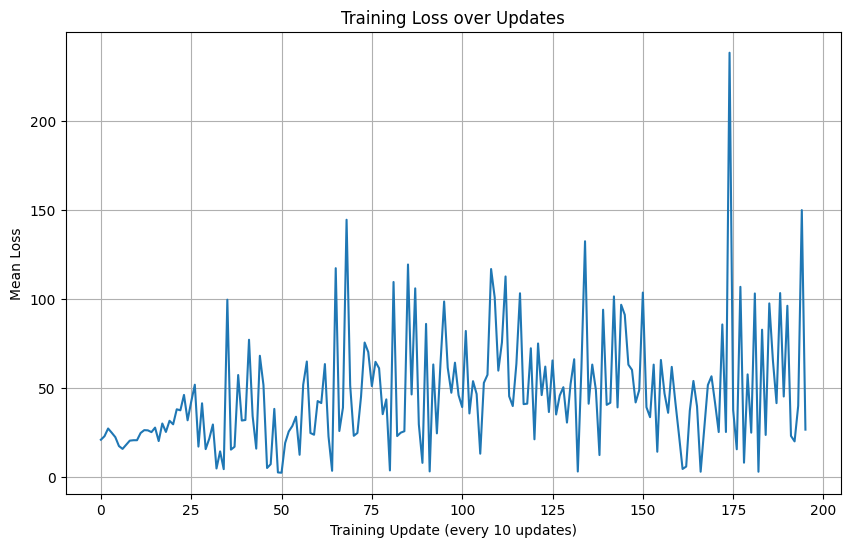

In [5]:
import matplotlib.pyplot as plt
import os

#os.environ['JAX_PLATFORMS'] = 'gpu'

rng = jax.random.PRNGKey(config["SEED"])
train_fn = make_train(config)

print("Starting PPO training...")
print(f"Environment: {config['ENV_NAME']}")
print(f"Number of environments: {config['NUM_ENVS']}")
print(f"Total updates: {config ['NUM_UPDATES']}")
print(f"Number of steps: {config['NUM_STEPS']}")
print(f"Number of minibatches: {config['NUM_MINIBATCHES']}")
print(f"Learning rate: {config['LEARNING_RATE']}")

final_train_state, loss_history = train_fn(rng)
print("Training complete!")

# Visualize the training loss
plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.xlabel("Training Update (every 10 updates)")
plt.ylabel("Mean Loss")
plt.title("Training Loss over Updates")
plt.grid(True)
plt.show()

## Snake Game

In [9]:
#import jax
#import jax.numpy as jnp
from typing import Tuple, Dict
import chex

@chex.dataclass
class EnvState:
    """State of the Snake environment"""
    snake_body: jnp.ndarray  # Snake body positions (MAX_LEN, 2)
    snake_head: jnp.ndarray  # Snake head position [x, y]
    snake_length: jnp.ndarray # Current length of the snake
    food_pos: jnp.ndarray    # Food position [x, y]
    direction: jnp.ndarray   # Current direction [dx, dy]
    score: jnp.ndarray       # Current score
    steps: jnp.ndarray       # Steps Taken
    done: jnp.ndarray        # Whether game is over

class SnakeEnv:
    """JAX-based Snake Environment"""

    def __init__(self, grid_size: int = 10, max_steps: int = 1000):
        self.grid_size = grid_size
        self.max_steps = max_steps
        self.action_space_size = 4  # up, down, left, right
        self.observation_space_size = grid_size * grid_size * 3  # snake, food, empty channels
        self.MAX_SNAKE_LEN = grid_size * grid_size # Maximum possible snake length

        # Action mappings: 0=up, 1=down, 2=left, 3=right
        self.actions = jnp.array(
            [[-1, 0],  # up
             [1, 0],   # down
             [0, -1],  # left
             [0, 1]]    # right
        )

    def reset(self, rng: chex.PRNGKey) -> Tuple[jnp.ndarray, EnvState]:
        """Reset the environment"""
        # Initialize snake in the center
        center = self.grid_size // 2
        snake_head = jnp.array([center, center])

        # Initialize snake_body as a fixed-size array, fill with dummy values (-1,-1)
        # and place the head at the first position.
        snake_body = jnp.full((self.MAX_SNAKE_LEN, 2), -1, dtype=jnp.int32)
        snake_body = snake_body.at[0].set(snake_head)
        snake_length = jnp.array(1, dtype=jnp.int32)

        # Random food position (not on snake, using the first segment)
        rng, food_rng = jax.random.split(rng)
        food_pos = self._generate_food(food_rng, snake_body, snake_length) # Pass full body and length

        # Initial direction (right)
        direction = jnp.array([0, 1])

        state = EnvState(
            snake_body=snake_body,
            snake_head=snake_head,
            snake_length=snake_length,
            food_pos=food_pos,
            direction=direction,
            score=jnp.array(0),
            steps=jnp.array(0),
            done=jnp.array(False)
        )

        obs = self._get_observation(state)
        return obs, state

    def step(self, state: EnvState, action: int, rng: chex.PRNGKey) -> Tuple[jnp.ndarray, EnvState, jnp.ndarray, jnp.ndarray, Dict]:
        """Step the environment"""
        # Don't allow 180-degree turns
        new_direction = self.actions[action]
        opposite_direction = -state.direction

        # If trying to go opposite direction, keep current direction
        direction = jnp.where(
            jnp.allclose(new_direction, opposite_direction),
            state.direction,
            new_direction
        )

        # Move snake head
        new_head = state.snake_head + direction

        # Check wall collision
        wall_collision = jnp.logical_or(
            jnp.logical_or(new_head[0] < 0, new_head[0] >= self.grid_size),
            jnp.logical_or(new_head[1] < 0, new_head[1] >= self.grid_size)
        )

        # Check self collision
        # Only check against active snake body segments
        self_collision = jnp.any(jnp.all(state.snake_body[:state.snake_length] == new_head, axis=1))

        # Check if food eaten
        food_eaten = jnp.allclose(new_head, state.food_pos)

        # Update snake body and length (JAX-compatible way)
        new_snake_length = jnp.where(food_eaten, state.snake_length + 1, state.snake_length)
        new_snake_length = jnp.minimum(new_snake_length, self.MAX_SNAKE_LEN) # Cap length at max

        # Create new body by shifting existing segments and adding new head
        # Shift all elements down by one.
        shifted_old_body = jnp.roll(state.snake_body, 1, axis=0)

        # Insert the new head at the beginning.
        new_body = shifted_old_body.at[0].set(new_head)

        # Generate new food if eaten
        rng, food_rng = jax.random.split(rng)
        new_food_pos = jnp.where(
            food_eaten,
            self._generate_food(food_rng, new_body, new_snake_length), # Pass updated body and length
            state.food_pos
        )

        # Calculate reward
        reward = jnp.where(
            wall_collision | self_collision, -10.0,  # Death penalty
            jnp.where(food_eaten, 10.0,              # Food reward
                     -0.01)                          # Small time penalty
        )

        # Update score
        new_score = state.score + jnp.where(food_eaten, 1, 0)

        # Check if done
        done = wall_collision | self_collision | (new_snake_length >= self.MAX_SNAKE_LEN) | (state.steps >= self.max_steps)

        new_state = EnvState(
            snake_body=new_body,
            snake_head=new_head,
            snake_length=new_snake_length, # Update length
            food_pos=new_food_pos,
            direction=direction,
            score=new_score,
            steps=state.steps + 1,
            done=done
        )

        obs = self._get_observation(new_state)
        info = {"score": new_score, "length": new_snake_length}

        return obs, new_state, reward, done, info

    def _generate_food(self, rng: chex.PRNGKey, snake_body: jnp.ndarray, snake_length: jnp.ndarray) -> jnp.ndarray:
        """Generate food position not on snake"""
        # Let's use a `while_loop` to ensure food is not on the snake.
        def condition_fn(val):
            i, current_food_pos, _ = val
            # Is food on snake? Only check active segments
            on_snake = jnp.any(jnp.all(snake_body[:snake_length] == current_food_pos, axis=1))
            return on_snake & (i < (self.grid_size * self.grid_size)) # Limit iterations

        def body_fn(val):
            i, _, current_rng = val
            current_rng, x_rng, y_rng = jax.random.split(current_rng, 3)
            new_x = jax.random.randint(x_rng, (), 0, self.grid_size)
            new_y = jax.random.randint(y_rng, (), 0, self.grid_size)
            new_pos = jnp.array([new_x, new_y])
            return i + 1, new_pos, current_rng

        # Initial loop state: (iteration_count, current_food_pos, rng)
        # Start with an initial random position
        rng, x_rng, y_rng = jax.random.split(rng, 3)
        initial_food_x = jax.random.randint(x_rng, (), 0, self.grid_size)
        initial_food_y = jax.random.randint(y_rng, (), 0, self.grid_size)
        initial_potential_food_pos = jnp.array([initial_food_x, initial_food_y])

        _, final_food_pos, _ = jax.lax.while_loop(condition_fn, body_fn, (0, initial_potential_food_pos, rng))

        return final_food_pos

    def _get_observation(self, state: EnvState) -> jnp.ndarray:
        """Get observation from state"""
        # Create 3-channel observation: snake, food, empty
        obs = jnp.zeros((self.grid_size, self.grid_size, 3))

        # Snake channel
        snake_grid = jnp.zeros((self.grid_size, self.grid_size))

        # Create indices for the active snake segments
        snake_indices = state.snake_body[:state.snake_length]

        # Filter out dummy values (e.g., -1, -1) that might exist beyond the actual snake length
        # and ensure indices are within grid bounds before setting.
        valid_indices_mask = (snake_indices >= 0).all(axis=-1) & \
                             (snake_indices[:, 0] < self.grid_size) & \
                             (snake_indices[:, 1] < self.grid_size)

        valid_snake_indices = snake_indices[valid_indices_mask]

        # Use jnp.scatter to set snake positions
        snake_grid = snake_grid.at[valid_snake_indices[:, 0], valid_snake_indices[:, 1]].set(1.0)

        # Food channel
        food_grid = jnp.zeros((self.grid_size, self.grid_size))
        food_grid = food_grid.at[state.food_pos[0], state.food_pos[1]].set(1.0)

        # Empty channel (inverse of snake)
        empty_grid = 1.0 - snake_grid

        obs = obs.at[:, :, 0].set(snake_grid)
        obs = obs.at[:, :, 1].set(food_grid)
        obs = obs.at[:, :, 2].set(empty_grid)

        # Flatten for the neural network
        return obs.flatten()

# Vectorized Snake Environment for PPO
def make_snake_env_batch(grid_size: int = 10, max_steps: int = 200):
    """Create a batch of Snake environments for vectorized training"""
    env = SnakeEnv(grid_size, max_steps)

    def reset_fn(rng): # rng here is expected to be a batch of keys
        """Reset function for vectorized environments"""
        return jax.vmap(env.reset)(rng)

    def step_fn(state, action, rngs): # rngs is a batch of keys, one for each env
        """Step function for vectorized environments"""
        return jax.vmap(env.step)(state, action, rngs)

    return reset_fn, step_fn, env

# Configuration for Snake
snake_config = {
    # Environment
    "ENV_NAME": "Snake",
    "GRID_SIZE": 8,
    "MAX_STEPS": 200,
    "NUM_ENVS": 16,

    # Training
    "TOTAL_TIMESTEPS": 5e5,
    "NUM_STEPS": 64,
    "NUM_EPOCHS": 4,
    "NUM_MINIBATCHES": 4,
    "LEARNING_RATE": 3e-4,

    # PPO Hyperparameters
    "GAMMA": 0.99,
    "GAE_LAMBDA": 0.95,
    "CLIP_EPS": 0.2,
    "ENT_COEF": 0.01,
    "VF_COEF": 0.5,

    # Network
    "ACTIVATION": "relu",
    "SEED": 42,
}

# Update derived configs
snake_config["NUM_UPDATES"] = int(snake_config["TOTAL_TIMESTEPS"] // (snake_config["NUM_STEPS"] * snake_config["NUM_ENVS"]))
snake_config["MINIBATCH_SIZE"] = int((snake_config["NUM_STEPS"] * snake_config["NUM_ENVS"]) // snake_config["NUM_MINIBATCHES"])

def make_snake_train(config):
    """Create Snake training function"""

    # Initialize Snake environment
    reset_fn, step_fn, env = make_snake_env_batch(config["GRID_SIZE"], config["MAX_STEPS"])

    obs_shape = (config["GRID_SIZE"] * config["GRID_SIZE"] * 3,)
    action_dim = 4  # Snake has 4 actions

    def linear_schedule(count):
        frac = 1.0 - (count // (config["NUM_MINIBATCHES"] * config["NUM_EPOCHS"])) / config["NUM_UPDATES"]
        return config["LEARNING_RATE"] * frac

    def train(rng):
        # Initialize network (using the ActorCritic from the main PPO code)
        from flax.training.train_state import TrainState
        import optax

        network = ActorCritic(action_dim, config["ACTIVATION"])

        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(obs_shape)
        network_params = network.init(_rng, init_x)

        tx = optax.chain(
            optax.clip_by_global_norm(0.5),
            optax.adam(learning_rate=linear_schedule, eps=1e-5)
        )
        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )

        # Initialize environments
        rng, _rng = jax.random.split(rng)
        reset_rngs = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = reset_fn(reset_rngs)

        # The rest would follow the same pattern as the CartPole example
        # but using the Snake step function

        print("Snake training setup complete!")
        print(f"Observation shape: {obs_shape}")
        print(f"Action dim: {action_dim}")
        print(f"Grid size: {config['GRID_SIZE']}x{config['GRID_SIZE']}")

        return train_state

    return train

if __name__ == "__main__":
    # Test the Snake environment
    rng = jax.random.PRNGKey(42) # Corrected typo: PRPRNGKey -> PRNGKey
    env = SnakeEnv(grid_size=8)

    obs, state = env.reset(rng)
    print(f"Initial observation shape: {obs.shape}")
    print(f"Initial score: {state.score}")
    print(f"Initial snake length: {state.snake_length}")

    # Take a few random steps
    for i in range(5):
        rng, step_rng = jax.random.split(rng)
        action = jax.random.randint(step_rng, (), 0, 4)
        # Pass a single step_rng here for the non-vmapped test environment
        obs, state, reward, done, info = env.step(state, action, step_rng)
        print(f"Step {i}: action={action}, reward={reward:.2f}, score={state.score}, length={state.snake_length}, done={done}")
        if done:
            break


Initial observation shape: (192,)
Initial score: 0
Initial snake length: 1
Step 0: action=1, reward=-0.01, score=0, length=1, done=False
Step 1: action=1, reward=-0.01, score=0, length=1, done=False
Step 2: action=2, reward=-0.01, score=0, length=1, done=False
Step 3: action=2, reward=-0.01, score=0, length=1, done=False
Step 4: action=2, reward=-0.01, score=0, length=1, done=False


In [12]:
#import jax
#import jax.numpy as jnp
from typing import Tuple, Dict
import chex

@chex.dataclass
class EnvState:
    """State of the Snake environment"""
    snake_body: jnp.ndarray  # Snake body positions [(x, y), ...] - fixed size array
    snake_length: jnp.ndarray  # Current length of snake
    food_pos: jnp.ndarray    # Food position [x, y]
    direction: jnp.ndarray   # Current direction [dx, dy]
    score: jnp.ndarray       # Current score
    steps: jnp.ndarray       # Steps taken
    done: jnp.ndarray        # Whether game is over

class SnakeEnv:
    """JAX-based Snake Environment"""

    def __init__(self, grid_size: int = 10, max_steps: int = 1000):
        self.grid_size = grid_size
        self.max_steps = max_steps
        self.max_snake_length = grid_size * grid_size  # Maximum possible snake length
        self.action_space_size = 4  # up, down, left, right
        self.observation_space_size = grid_size * grid_size * 3  # snake, food, empty channels

        # Action mappings: 0=up, 1=down, 2=left, 3=right
        self.actions = jnp.array([
            [-1, 0],  # up
            [1, 0],   # down
            [0, -1],  # left
            [0, 1]    # right
        ])

    def reset(self, rng: chex.PRNGKey) -> Tuple[jnp.ndarray, EnvState]:
        """Reset the environment"""
        # Initialize snake in the center with length 3
        center = self.grid_size // 2

        # Create fixed-size snake body array (filled with zeros, only first few are valid)
        snake_body = jnp.zeros((self.max_snake_length, 2), dtype=jnp.int32)
        snake_body = snake_body.at[0].set(jnp.array([center, center]))
        snake_body = snake_body.at[1].set(jnp.array([center, center - 1]))
        snake_body = snake_body.at[2].set(jnp.array([center, center - 2]))

        snake_length = jnp.array(3)

        # Random food position (not on snake)
        rng, food_rng = jax.random.split(rng)
        food_pos = self._generate_food(food_rng, snake_body, snake_length)

        # Initial direction (right)
        direction = jnp.array([0, 1])

        state = EnvState(
            snake_body=snake_body,
            snake_length=snake_length,
            food_pos=food_pos,
            direction=direction,
            score=jnp.array(0),
            steps=jnp.array(0),
            done=jnp.array(False)
        )

        obs = self._get_observation(state)
        return obs, state

    def step(self, state: EnvState, action: int, rng: chex.PRNGKey) -> Tuple[jnp.ndarray, EnvState, jnp.ndarray, jnp.ndarray, Dict]:
        """Step the environment"""
        # Get current snake head (first position in body)
        snake_head = state.snake_body[0]

        # Don't allow 180-degree turns
        new_direction = self.actions[action]
        opposite_direction = -state.direction

        # If trying to go opposite direction, keep current direction
        direction = jnp.where(
            jnp.allclose(new_direction, opposite_direction),
            state.direction,
            new_direction
        )

        # Move snake head
        new_head = snake_head + direction

        # Check wall collision
        wall_collision = jnp.logical_or(
            jnp.logical_or(new_head[0] < 0, new_head[0] >= self.grid_size),
            jnp.logical_or(new_head[1] < 0, new_head[1] >= self.grid_size)
        )

        # Check self collision (only check against valid snake body positions)
        # Create mask for valid body positions
        valid_body_mask = jnp.arange(self.max_snake_length) < state.snake_length
        self_collision = jnp.any(
            jnp.logical_and(
                jnp.all(state.snake_body == new_head, axis=1),
                valid_body_mask
            )
        )

        # Check if food eaten
        food_eaten = jnp.allclose(new_head, state.food_pos)

        # Update snake body: shift all positions back and add new head
        new_body = jnp.roll(state.snake_body, 1, axis=0)
        new_body = new_body.at[0].set(new_head)

        # Update snake length (grow if food eaten, max at max_snake_length)
        new_length = jnp.minimum(
            state.snake_length + jnp.where(food_eaten, 1, 0),
            self.max_snake_length
        )

        # Generate new food if eaten
        rng, food_rng = jax.random.split(rng)
        new_food_candidate = self._generate_food(food_rng, new_body, new_length)
        new_food_pos = jax.lax.cond(
            food_eaten,
            lambda: new_food_candidate,
            lambda: state.food_pos
        )

        # Calculate reward
        collision = wall_collision | self_collision
        reward = jax.lax.cond(
            collision,
            lambda: jnp.array(-10.0),
            lambda: jax.lax.cond(
                food_eaten,
                lambda: jnp.array(10.0),
                lambda: jnp.array(-0.01)
            )
        )

        # Update score
        new_score = state.score + jnp.where(food_eaten, 1, 0)

        # Check if done
        done = collision | (state.steps >= self.max_steps)

        new_state = EnvState(
            snake_body=new_body,
            snake_length=new_length,
            food_pos=new_food_pos,
            direction=direction,
            score=new_score,
            steps=state.steps + 1,
            done=done
        )

        obs = self._get_observation(new_state)
        info = {"score": new_score, "length": new_length}

        return obs, new_state, reward, done, info

    def _generate_food(self, rng: chex.PRNGKey, snake_body: jnp.ndarray, snake_length: jnp.ndarray) -> jnp.ndarray:
        """Generate food position not on snake"""
        # Simple approach: random position (might overlap with snake, but rare for small snakes)
        rng_x, rng_y = jax.random.split(rng)
        food_x = jax.random.randint(rng_x, (), 0, self.grid_size)
        food_y = jax.random.randint(rng_y, (), 0, self.grid_size)
        return jnp.array([food_x, food_y])

    def _get_observation(self, state: EnvState) -> jnp.ndarray:
        """Get observation from state"""
        # Create 3-channel observation: snake, food, empty
        obs = jnp.zeros((self.grid_size, self.grid_size, 3))

        # Snake channel - only mark valid body positions
        snake_grid = jnp.zeros((self.grid_size, self.grid_size))

        # Use a loop to set snake body positions (only valid ones)
        def set_snake_pos(i, grid):
            pos = state.snake_body[i]
            # Only set if this is a valid position (i < snake_length)
            grid = jnp.where(
                i < state.snake_length,
                grid.at[pos[0], pos[1]].set(1.0),
                grid
            )
            return grid

        snake_grid = jax.lax.fori_loop(0, self.max_snake_length, set_snake_pos, snake_grid)

        # Food channel
        food_grid = jnp.zeros((self.grid_size, self.grid_size))
        food_grid = food_grid.at[state.food_pos[0], state.food_pos[1]].set(1.0)

        # Empty channel (inverse of snake)
        empty_grid = 1.0 - snake_grid

        obs = obs.at[:, :, 0].set(snake_grid)
        obs = obs.at[:, :, 1].set(food_grid)
        obs = obs.at[:, :, 2].set(empty_grid)

        # Flatten for the neural network
        return obs.flatten()

# Vectorized Snake Environment for PPO
def make_snake_env_batch(grid_size: int = 10, max_steps: int = 200):
    """Create a batch of Snake environments for vectorized training"""
    env = SnakeEnv(grid_size, max_steps)

    def reset_fn(rng):
        """Reset function for vectorized environments"""
        return jax.vmap(env.reset)(rng)

    def step_fn(rng, state, action):
        """Step function for vectorized environments"""
        return jax.vmap(env.step, in_axes=(0, 0, None))(state, rng, action)

    return reset_fn, step_fn, env

# Configuration for Snake
snake_config = {
    # Environment
    "ENV_NAME": "Snake",
    "GRID_SIZE": 8,
    "MAX_STEPS": 200,
    "NUM_ENVS": 16,

    # Training
    "TOTAL_TIMESTEPS": 5e5,
    "NUM_STEPS": 64,
    "NUM_EPOCHS": 4,
    "NUM_MINIBATCHES": 4,
    "LEARNING_RATE": 3e-4,

    # PPO Hyperparameters
    "GAMMA": 0.99,
    "GAE_LAMBDA": 0.95,
    "CLIP_EPS": 0.2,
    "ENT_COEF": 0.01,
    "VF_COEF": 0.5,

    # Network
    "ACTIVATION": "relu",
    "SEED": 42,
}

# Update derived configs
snake_config["NUM_UPDATES"] = int(snake_config["TOTAL_TIMESTEPS"] // (snake_config["NUM_STEPS"] * snake_config["NUM_ENVS"]))
snake_config["MINIBATCH_SIZE"] = int((snake_config["NUM_STEPS"] * snake_config["NUM_ENVS"]) // snake_config["NUM_MINIBATCHES"])

def make_snake_train(config):
    """Create Snake training function"""

    # Initialize Snake environment
    reset_fn, step_fn, env = make_snake_env_batch(config["GRID_SIZE"], config["MAX_STEPS"])

    obs_shape = (config["GRID_SIZE"] * config["GRID_SIZE"] * 3,)
    action_dim = 4  # Snake has 4 actions

    def linear_schedule(count):
        frac = 1.0 - (count // (config["NUM_MINIBATCHES"] * config["NUM_EPOCHS"])) / config["NUM_UPDATES"]
        return config["LEARNING_RATE"] * frac

    def train(rng):
        # Initialize network (using the ActorCritic from the main PPO code)
        from flax.training.train_state import TrainState
        import optax

        network = ActorCritic(action_dim, config["ACTIVATION"])

        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(obs_shape)
        network_params = network.init(_rng, init_x)

        tx = optax.chain(
            optax.clip_by_global_norm(0.5),
            optax.adam(learning_rate=linear_schedule, eps=1e-5)
        )
        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )

        # Initialize environments
        rng, _rng = jax.random.split(rng)
        reset_rngs = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = reset_fn(reset_rngs)

        # The rest would follow the same pattern as the CartPole example
        # but using the Snake step function

        print("Snake training setup complete!")
        print(f"Observation shape: {obs_shape}")
        print(f"Action dim: {action_dim}")
        print(f"Grid size: {config['GRID_SIZE']}x{config['GRID_SIZE']}")

        return train_state

    return train

if __name__ == "__main__":
    # Test the Snake environment
    rng = jax.random.PRNGKey(42)
    env = SnakeEnv(grid_size=8)

    obs, state = env.reset(rng)
    print(f"Initial observation shape: {obs.shape}")
    print(f"Initial score: {state.score}")

    # Take a few random steps
    for i in range(100):
        rng, step_rng = jax.random.split(rng)
        action = jax.random.randint(step_rng, (), 0, 4)
        obs, state, reward, done, info = env.step(state, action, step_rng)
        print(f"Step {i}: action={action}, reward={reward:.2f}, score={state.score}, done={done}")
        if done:
            break

Initial observation shape: (192,)
Initial score: 0
Step 0: action=1, reward=-0.01, score=0, done=False
Step 1: action=1, reward=-0.01, score=0, done=False
Step 2: action=2, reward=-0.01, score=0, done=False
Step 3: action=2, reward=-0.01, score=0, done=False
Step 4: action=2, reward=-0.01, score=0, done=False
Step 5: action=2, reward=-0.01, score=0, done=False
Step 6: action=1, reward=10.00, score=1, done=False
Step 7: action=2, reward=-10.00, score=1, done=True


🚀 Ready for Training!

The environment is working perfectly! Now we can:

- Train the PPO agent to learn to play Snake
- Watch it learn to:

  * Avoid walls and its own body
  * Navigate toward food efficiently
  * Plan ahead to not trap itself


The agent will start playing randomly (like this) but will gradually learn optimal strategies!

In [20]:
from functools import partial

# ==================== SNAKE ENVIRONMENT ====================
@chex.dataclass
class EnvState:
    """State of the Snake environment"""
    snake_body: jnp.ndarray  # Snake body positions - fixed size array
    snake_length: jnp.ndarray  # Current length of snake
    food_pos: jnp.ndarray    # Food position [x, y]
    direction: jnp.ndarray   # Current direction [dx, dy]
    score: jnp.ndarray       # Current score
    steps: jnp.ndarray       # Steps taken
    done: jnp.ndarray        # Whether game is over

class SnakeEnv:
    """JAX-based Snake Environment"""

    def __init__(self, grid_size: int = 10, max_steps: int = 1000):
        self.grid_size = grid_size
        self.max_steps = max_steps
        self.max_snake_length = grid_size * grid_size
        self.action_space_size = 4
        self.observation_space_size = grid_size * grid_size * 3

        self.actions = jnp.array([
            [-1, 0],  # up
            [1, 0],   # down
            [0, -1],  # left
            [0, 1]    # right
        ])

    def reset(self, rng: chex.PRNGKey) -> Tuple[jnp.ndarray, EnvState]:
        """Reset the environment"""
        center = self.grid_size // 2

        snake_body = jnp.zeros((self.max_snake_length, 2), dtype=jnp.int32)
        snake_body = snake_body.at[0].set(jnp.array([center, center]))
        snake_body = snake_body.at[1].set(jnp.array([center, center - 1]))
        snake_body = snake_body.at[2].set(jnp.array([center, center - 2]))

        snake_length = jnp.array(3)

        rng, food_rng = jax.random.split(rng)
        food_pos = self._generate_food(food_rng, snake_body, snake_length)

        direction = jnp.array([0, 1])

        state = EnvState(
            snake_body=snake_body,
            snake_length=snake_length,
            food_pos=food_pos,
            direction=direction,
            score=jnp.array(0),
            steps=jnp.array(0),
            done=jnp.array(False)
        )

        obs = self._get_observation(state)
        return obs, state

    def step(self, state: EnvState, action: int, rng: chex.PRNGKey) -> Tuple[jnp.ndarray, EnvState, jnp.ndarray, jnp.ndarray, Dict]:
        """Step the environment"""
        snake_head = state.snake_body[0]

        new_direction = self.actions[action]
        opposite_direction = -state.direction

        direction = jnp.where(
            jnp.allclose(new_direction, opposite_direction),
            state.direction,
            new_direction
        )

        new_head = snake_head + direction

        wall_collision = jnp.logical_or(
            jnp.logical_or(new_head[0] < 0, new_head[0] >= self.grid_size),
            jnp.logical_or(new_head[1] < 0, new_head[1] >= self.grid_size)
        )

        valid_body_mask = jnp.arange(self.max_snake_length) < state.snake_length
        self_collision = jnp.any(
            jnp.logical_and(
                jnp.all(state.snake_body == new_head, axis=1),
                valid_body_mask
            )
        )

        food_eaten = jnp.allclose(new_head, state.food_pos)

        new_body = jnp.roll(state.snake_body, 1, axis=0)
        new_body = new_body.at[0].set(new_head)

        new_length = jnp.minimum(
            state.snake_length + jnp.where(food_eaten, 1, 0),
            self.max_snake_length
        )

        rng, food_rng = jax.random.split(rng)
        new_food_candidate = self._generate_food(food_rng, new_body, new_length)
        new_food_pos = jax.lax.cond(
            food_eaten,
            lambda: new_food_candidate,
            lambda: state.food_pos
        )

        collision = wall_collision | self_collision

        # Better reward shaping
        dist_to_food = jnp.abs(new_head[0] - state.food_pos[0]) + jnp.abs(new_head[1] - state.food_pos[1])
        old_dist_to_food = jnp.abs(snake_head[0] - state.food_pos[0]) + jnp.abs(snake_head[1] - state.food_pos[1])
        closer_to_food = old_dist_to_food - dist_to_food

        reward = jax.lax.cond(
            collision,
            lambda: jnp.array(-1.0),
            lambda: jax.lax.cond(
                food_eaten,
                lambda: jnp.array(1.0),
                lambda: jnp.array(0.01 * closer_to_food)
            )
        )

        new_score = state.score + jnp.where(food_eaten, 1, 0)
        done = collision | (state.steps >= self.max_steps)

        new_state = EnvState(
            snake_body=new_body,
            snake_length=new_length,
            food_pos=new_food_pos,
            direction=direction,
            score=new_score,
            steps=state.steps + 1,
            done=done
        )

        obs = self._get_observation(new_state)
        info = {"score": new_score, "length": new_length}

        return obs, new_state, reward, done, info

    def _generate_food(self, rng: chex.PRNGKey, snake_body: jnp.ndarray, snake_length: jnp.ndarray) -> jnp.ndarray:
        """Generate food position"""
        rng_x, rng_y = jax.random.split(rng)
        food_x = jax.random.randint(rng_x, (), 0, self.grid_size)
        food_y = jax.random.randint(rng_y, (), 0, self.grid_size)
        return jnp.array([food_x, food_y])

    def _get_observation(self, state: EnvState) -> jnp.ndarray:
        """Get observation from state"""
        obs = jnp.zeros((self.grid_size, self.grid_size, 3))

        snake_grid = jnp.zeros((self.grid_size, self.grid_size))

        def set_snake_pos(i, grid):
            pos = state.snake_body[i]
            grid = jnp.where(
                i < state.snake_length,
                grid.at[pos[0], pos[1]].set(1.0),
                grid
            )
            return grid

        snake_grid = jax.lax.fori_loop(0, self.max_snake_length, set_snake_pos, snake_grid)

        food_grid = jnp.zeros((self.grid_size, self.grid_size))
        food_grid = food_grid.at[state.food_pos[0], state.food_pos[1]].set(1.0)

        empty_grid = 1.0 - snake_grid

        obs = obs.at[:, :, 0].set(snake_grid)
        obs = obs.at[:, :, 1].set(food_grid)
        obs = obs.at[:, :, 2].set(empty_grid)

        return obs.flatten()

# ==================== PPO COMPONENTS ====================

class Transition(NamedTuple):
    """Data structure to store environment transitions"""
    done: jnp.ndarray
    action: jnp.ndarray
    value: jnp.ndarray
    reward: jnp.ndarray
    log_prob: jnp.ndarray
    obs: jnp.ndarray
    info: dict

class ActorCritic(nn.Module):
    """Actor Critic Network."""
    action_dim: int
    activation: str = "tanh"

    @nn.compact
    def __call__(self, x):
        if self.activation == 'relu':
            activation = nn.relu
        else:
            activation = nn.tanh

        # Shared layers
        shared = nn.Dense(128, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(x)
        shared = activation(shared)
        shared = nn.Dense(128, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0))(shared)
        shared = activation(shared)

        # Actor head
        actor_mean = nn.Dense(
            self.action_dim,
            kernel_init=orthogonal(0.01),
            bias_init=constant(0.0)
        )(shared)
        pi = distrax.Categorical(logits=actor_mean)

        # Critic head
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0))(shared)

        return pi, jnp.squeeze(critic, axis=-1)

# ==================== CONFIGURATION ====================

config = {
    # Environment
    "ENV_NAME": "Snake",
    "GRID_SIZE": 8,
    "MAX_STEPS": 500,
    "NUM_ENVS": 32,

    # Training
    "TOTAL_TIMESTEPS": 2e6,
    "NUM_STEPS": 128,
    "NUM_EPOCHS": 4,
    "NUM_MINIBATCHES": 4,
    "LEARNING_RATE": 5e-4,

    # PPO Hyperparameters
    "GAMMA": 0.99,
    "GAE_LAMBDA": 0.95,
    "CLIP_EPS": 0.2,
    "ENT_COEF": 0.02,
    "VF_COEF": 0.5,

    # Network
    "ACTIVATION": "relu",
    "SEED": 42,
}

config["NUM_UPDATES"] = int(config["TOTAL_TIMESTEPS"] // (config["NUM_STEPS"] * config["NUM_ENVS"]))
config["MINIBATCH_SIZE"] = int((config["NUM_STEPS"] * config["NUM_ENVS"]) // config["NUM_MINIBATCHES"])

# ==================== TRAINING FUNCTION ====================

def make_train(config):
    """Creates the training function"""

    env = SnakeEnv(config["GRID_SIZE"], config["MAX_STEPS"])

    # Vectorize environment functions
    vmap_reset = jax.vmap(env.reset)
    vmap_step = jax.vmap(env.step)

    obs_shape = (config["GRID_SIZE"] * config["GRID_SIZE"] * 3,)
    action_dim = 4

    def linear_schedule(count):
        frac = 1.0 - (count // (config["NUM_MINIBATCHES"] * config["NUM_EPOCHS"])) / config["NUM_UPDATES"]
        return config["LEARNING_RATE"] * frac

    def train(rng):
        # Initialize network
        network = ActorCritic(action_dim, config["ACTIVATION"])

        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(obs_shape)
        network_params = network.init(_rng, init_x)

        tx = optax.chain(
            optax.clip_by_global_norm(0.5),
            optax.adam(learning_rate=linear_schedule, eps=1e-5)
        )
        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )

        # Environment step function
        def env_step(runner_state, unused):
            train_state, env_state, last_obs, rng = runner_state

            # Select action
            rng, _rng = jax.random.split(rng)
            pi, value = network.apply(train_state.params, last_obs)
            action = pi.sample(seed=_rng)
            log_prob = pi.log_prob(action)

            # Step environments
            rng, _rng = jax.random.split(rng)
            rng_step = jax.random.split(_rng, config["NUM_ENVS"])
            obs, env_state, reward, done, info = vmap_step(env_state, action, rng_step)

            # Reset environments that are done
            rng, _rng = jax.random.split(rng)
            rng_reset = jax.random.split(_rng, config["NUM_ENVS"])
            obs_reset, env_state_reset = vmap_reset(rng_reset)

            # 1. Handle Observation Reset (Standard Broadcast)
            obs = jnp.where(done[:, None], obs_reset, obs)

            # 2. Handle EnvState Reset (Custom Broadcasting per Leaf)
            def where_leaf(leaf_reset, leaf_current):
                # We need to reshape 'done' to match the dimensionality of the specific leaf.
                # leaf shape is (batch, ...). done is (batch,).
                # dims_to_append = leaf.ndim - 1
                dims_to_append = leaf_reset.ndim - 1
                done_reshaped = done.reshape(done.shape + (1,) * dims_to_append)
                return jnp.where(done_reshaped, leaf_reset, leaf_current)

            env_state = jax.tree_util.tree_map(
                where_leaf,
                env_state_reset,
                env_state
            )

            transition = Transition(
                done=done,
                action=action,
                value=value,
                reward=reward,
                log_prob=log_prob,
                obs=last_obs,
                info=info
            )

            runner_state = (train_state, env_state, obs, rng)
            return runner_state, transition

        def calculate_gae(traj_batch, last_val):
            def get_advantages(gae_and_next_value, transition):
                gae, next_value = gae_and_next_value
                done, value, reward = transition.done, transition.value, transition.reward

                delta = reward + config["GAMMA"] * next_value * (1 - done) - value
                gae = delta + config["GAMMA"] * config["GAE_LAMBDA"] * (1 - done) * gae

                return (gae, value), gae

            _, advantages = jax.lax.scan(
                get_advantages,
                (jnp.zeros_like(last_val), last_val),
                traj_batch,
                reverse=True,
            )
            return advantages, advantages + traj_batch.value

        def update_epoch(update_state, unused):
            def update_minibatch(train_state, batch_info):
                traj_batch, advantages, targets = batch_info

                def loss_fn(params):
                    pi, value = network.apply(params, traj_batch.obs)
                    log_prob = pi.log_prob(traj_batch.action)

                    # Policy loss
                    ratio = jnp.exp(log_prob - traj_batch.log_prob)
                    gae = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

                    loss_actor1 = ratio * gae
                    loss_actor2 = jnp.clip(ratio, 1.0 - config["CLIP_EPS"], 1.0 + config["CLIP_EPS"]) * gae
                    loss_actor = -jnp.minimum(loss_actor1, loss_actor2).mean()

                    # Value loss
                    value_pred_clipped = traj_batch.value + (value - traj_batch.value).clip(-config["CLIP_EPS"], config["CLIP_EPS"])
                    value_losses = jnp.square(value - targets)
                    value_losses_clipped = jnp.square(value_pred_clipped - targets)
                    value_loss = 0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()

                    # Entropy loss
                    entropy = pi.entropy().mean()

                    total_loss = (
                        loss_actor
                        + config["VF_COEF"] * value_loss
                        - config["ENT_COEF"] * entropy
                    )
                    return total_loss, (value_loss, loss_actor, entropy)

                grad_fn = jax.value_and_grad(loss_fn, has_aux=True)
                total_loss, grads = grad_fn(train_state.params)
                train_state = train_state.apply_gradients(grads=grads)
                return train_state, total_loss

            train_state, traj_batch, advantages, targets, rng = update_state

            rng, _rng = jax.random.split(rng)
            batch_size = config["MINIBATCH_SIZE"] * config["NUM_MINIBATCHES"]

            permutation = jax.random.permutation(_rng, batch_size)
            batch = (traj_batch, advantages, targets)
            batch = jax.tree_util.tree_map(
                lambda x: x.reshape((batch_size,) + x.shape[2:]), batch
            )
            shuffled_batch = jax.tree_util.tree_map(
                lambda x: jnp.take(x, permutation, axis=0), batch
            )
            minibatches = jax.tree_util.tree_map(
                lambda x: jnp.reshape(x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])),
                shuffled_batch,
            )

            train_state, total_loss = jax.lax.scan(update_minibatch, train_state, minibatches)
            update_state = (train_state, traj_batch, advantages, targets, rng)
            return update_state, total_loss

        # Initialize environments
        rng, _rng = jax.random.split(rng)
        reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = vmap_reset(reset_rng)

        # Training loop
        rng, _rng = jax.random.split(rng)
        runner_state = (train_state, env_state, obsv, _rng)

        print(f"\n🐍 Starting Snake PPO Training!")
        print(f"📊 Total updates: {config['NUM_UPDATES']}")
        print(f"🎮 Environments: {config['NUM_ENVS']}")
        print(f"📦 Steps per rollout: {config['NUM_STEPS']}")
        print(f"🧠 Network size: 128x128")
        print("="*50 + "\n")

        for update in range(config["NUM_UPDATES"]):
            # Collect rollout
            runner_state, traj_batch = jax.lax.scan(
                env_step, runner_state, None, config["NUM_STEPS"]
            )

            # Calculate advantages
            train_state, env_state, last_obs, rng = runner_state
            _, last_val = network.apply(train_state.params, last_obs)
            advantages, targets = calculate_gae(traj_batch, last_val)

            # Update network
            rng, _rng = jax.random.split(rng)
            update_state = (train_state, traj_batch, advantages, targets, _rng)
            update_state, loss_info = jax.lax.scan(
                update_epoch, update_state, None, config["NUM_EPOCHS"]
            )

            train_state = update_state[0]
            runner_state = (train_state, env_state, last_obs, rng)

            # Log progress
            if update % 20 == 0:
                mean_return = traj_batch.reward.sum(axis=0).mean()
                mean_score = traj_batch.info["score"][-1].mean()
                mean_length = traj_batch.info["length"][-1].mean()

                print(f"Update {update:4d}/{config['NUM_UPDATES']} | "
                      f"Return: {mean_return:6.2f} | "
                      f"Score: {mean_score:4.1f} | "
                      f"Length: {mean_length:4.1f} | "
                      f"Loss: {loss_info[0].mean():.4f}")

        print("\n" + "="*50)
        print("🎉 Training completed!")
        return train_state

    return train

# ==================== RUN TRAINING ====================

if __name__ == "__main__":
    rng = jax.random.PRNGKey(config["SEED"])
    train_fn = make_train(config)
    final_train_state = train_fn(rng)

    print("\n✅ Training finished! You now have a trained Snake-playing agent!")
    print("💾 Save the final_train_state to use the trained policy later.")


🐍 Starting Snake PPO Training!
📊 Total updates: 488
🎮 Environments: 32
📦 Steps per rollout: 128
🧠 Network size: 128x128

Update    0/488 | Return: -10.66 | Score:  0.1 | Length:  3.1 | Loss: 0.0477
Update   20/488 | Return:  -3.56 | Score:  0.1 | Length:  3.1 | Loss: 0.0012
Update   40/488 | Return:   0.25 | Score:  1.0 | Length:  4.0 | Loss: 0.0163
Update   60/488 | Return:   1.47 | Score:  2.0 | Length:  5.0 | Loss: 0.0532
Update   80/488 | Return:   0.82 | Score:  2.2 | Length:  5.2 | Loss: 0.0261
Update  100/488 | Return:   1.94 | Score:  3.4 | Length:  6.4 | Loss: 0.0443
Update  120/488 | Return:   2.41 | Score:  4.2 | Length:  7.2 | Loss: 0.0302
Update  140/488 | Return:   2.30 | Score:  4.3 | Length:  7.3 | Loss: 0.0562
Update  160/488 | Return:   1.99 | Score:  4.7 | Length:  7.7 | Loss: 0.0429
Update  180/488 | Return:   3.34 | Score:  5.0 | Length:  8.0 | Loss: 0.0763
Update  200/488 | Return:   3.22 | Score:  7.0 | Length: 10.0 | Loss: 0.0234
Update  220/488 | Return:   3.0